# Installations and Imports

In [ ]:
# Installation
!pip -q install "huggingface_hub" "transformers>=4.43.3" "accelerate>=0.33.0" "bitsandbytes>=0.43.0" "sentencepiece>=0.2.0" "huggingface_hub>=0.24.0" "einops>=0.8.0" safetensors
!python -m spacy download en_core_web_lg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Imports
import re
import numpy as np
import pandas as pd
import os
import json
import random
import pickle
import sys
import ast

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_rgba

from scipy.spatial import ConvexHull
import plotly.graph_objects as go
import plotly.io as pio

import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
import platform

import spacy
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from IPython.display import display, HTML

from transformers import AutoTokenizer, AutoModelForCausalLM

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Set Up

In [ ]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Using CPU


In [ ]:
# Login with your hf token
from huggingface_hub import login
login("insert_your_hf_token")

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set this for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# Load Models

In [ ]:
# Define model id
model_id = "meta-llama/Llama-3.1-8B-Instruct"

In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# Set pad tokens
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
# Load model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto",          # automatically spreads across GPU/CPU if needed
    low_cpu_mem_usage=True
).eval()                        # set to evaluation mode

# Set pad tokens
model.config.pad_token_id = model.config.eos_token_id

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
# Load spacy model for POS tagging
nlp = spacy.load("en_core_web_lg")  # or en_core_web_sm

# Utils

In [ ]:
def tidy(tok):
  #remove common artifacts from GPT-2/BPE or SentencePiece
  return re.sub(r"[ÂĠ▁ĊĿĻĽâĢĻł]", "", tok)

# Convert color names to RGBA strings with alpha
def rgba_color(color_name, alpha):
    r, g, b, _ = to_rgba(color_name)
    return f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {alpha})"

# Filter stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(string.punctuation)

# Define custom stopwords
custom_stopwords = {'egg', 'hen', 'problem', 'solution'}
stop_words.update(custom_stopwords)

def is_stopword(tok) -> bool:
    """
    Return True if token should be excluded:
      - English stopword (case-insensitive)
      - punctuation
      - all digits
      - empty string
    """
    return (
        (tok.lower() in stop_words)
        or tok.isdigit()
        or (tok == "")
    )

# Load Prompts

In [ ]:
# Load prompts
df = pd.read_excel("/content/drive/MyDrive/data/prompts.xlsx")
df["config_dict"] = df["config_dict"].apply(ast.literal_eval)
df

,prompt_id,prompt_category,prompt_shot,prompt_type,prompt,config,config_dict
0,1,open_prompt,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,greedy_decoding,"{'do_sample': False, 'num_beams': 1, 'temperat..."
1,2,open_prompt,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,low_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."
2,3,open_prompt,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."
3,4,open_prompt,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,high_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."
4,5,open_prompt,zero_shot,2,"Problem: Design the most creative, novel, and ...",greedy_decoding,"{'do_sample': False, 'num_beams': 1, 'temperat..."
...,...,...,...,...,...,...,...
83,84,negate_fix,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,high_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."
84,85,negate_fix,zero_shot,2,"Problem: Design the most creative, novel, and ...",greedy_decoding,"{'do_sample': False, 'num_beams': 1, 'temperat..."
85,86,negate_fix,zero_shot,2,"Problem: Design the most creative, novel, and ...",low_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."
86,87,negate_fix,zero_shot,2,"Problem: Design the most creative, novel, and ...",mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu..."


# Create Batches

In [ ]:
batch_list = []
batch_id = 0

# Create batch based on config values
for config, group in df.groupby("config"):
    n = len(group)
    index_splits = np.array_split(np.arange(n), np.arange(6, n, 6))
    for idx in index_splits:
        chunk = group.iloc[idx].copy()
        chunk["batch_id"] = batch_id
        batch_list.append(chunk)
        batch_id += 1

df_batches = pd.concat(batch_list, ignore_index=True)
df_batches

# Select Batch

In [ ]:
# Select Batch ID
batch_id = 15
df_batch = df_batches.query(f"batch_id == {batch_id}")
df_batch

,prompt_id,prompt_category,prompt_shot,prompt_type,prompt,config,config_dict,batch_id
84,75,prop_of_env,few_shot,1,Problem: Design a way to drop a hen’s egg from...,mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu...",15
85,79,prop_of_env,few_shot,1,Problem: Design a way to drop a hen’s egg from...,mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu...",15
86,83,negate_fix,zero_shot,1,Problem: Design a way to drop a hen’s egg from...,mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu...",15
87,87,negate_fix,zero_shot,2,"Problem: Design the most creative, novel, and ...",mid_temp,"{'do_sample': True, 'num_beams': 1, 'temperatu...",15


# Extract Hidden States


In [ ]:
# Set prompts
prompts = df_batch['prompt'].tolist()

# Set generation parameters
gen_config = df_batch['config_dict'].iloc[0]
print(gen_config)

{'do_sample': True, 'num_beams': 1, 'temperature': 0.6, 'top_p': 0.92, 'top_k': 60}


In [ ]:
# Encode prompts (inputs)
encodings = tokenizer(
    prompts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    add_special_tokens=True,
)

# B = num of prompts
# T = num of tokens of the longest sequence in the batch
input_ids = encodings.input_ids.to(model.device)                # [B, T]
attention_mask = encodings.attention_mask.to(model.device)      # [B, T]
B, T = input_ids.shape

with torch.no_grad():
    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict_in_generate=True,
        output_hidden_states=True,       # get hidden states
        output_scores=True,              # get per-step logits
        use_cache=True,
        # set generation params:
        max_new_tokens=30,               # num_steps
        **gen_config
    )

# Full generated sequences (including prompt + new tokens)
generated_ids = outputs.sequences     # [B, T + num_steps]
new_token_ids = generated_ids[:, T:]  # [B, num_steps]


# Hidden states per generation step:--------------------------------------------
#   outputs.hidden_states is a tuple of length = num_steps
#   For step s:
#       step_hidden = outputs.hidden_states[s]
#       step_hidden is a tuple (layer0, layer1, ..., layerN)
#       each layer tensor has shape [B, current_seq_len, H]
hidden_states_per_step = outputs.hidden_states

num_steps = len(hidden_states_per_step)
H = hidden_states_per_step[0][-1].size(-1)

# Get last-layer hidden state for the newly generated token at each generation step
step_last_token_hidden_list = []  # list of [B, H]
for step_hidden in hidden_states_per_step:
    last_layer_hidden = step_hidden[-1]              # [B, current_seq_len, H]
    new_token_hidden  = last_layer_hidden[:, -1, :]  # [B, H]
    step_last_token_hidden_list.append(new_token_hidden)


# Logits for each generation step: ---------------------------------------------
#   outputs.scores is a tuple of length = num_steps
#   For step s:
#       step_scores = outputs.scores[s]
#       outputs.scores is a tensor of shape [B, V] where V is the vocabulary size.
scores_per_step = outputs.scores

topk = 5 # get top 5 ids and logits
topk_scores_list, topk_ids_list = [], []
for step_scores in scores_per_step:
    # Convert scores to probabilities if you want probs (optional)
    step_probs = step_scores.softmax(dim=-1) # [B, V]
    step_topk_probs, step_topk_ids = torch.topk(step_probs, k=topk, dim=-1)  # [B, topk]
    topk_scores_list.append(step_topk_probs)
    topk_ids_list.append(step_topk_ids)

# Stack into one tensor
step_last_token_hidden_tensor = torch.stack(step_last_token_hidden_list, dim=1) # [B, num_steps, H]
topk_probs_tensor = torch.stack(topk_scores_list, dim=1)  # [B, num_steps, topk]
topk_ids_tensor   = torch.stack(topk_ids_list, dim=1)    # [B, num_steps, topk]

# Convert to numpy
step_last_token_hidden_np = step_last_token_hidden_tensor.to(dtype=torch.float32, device="cpu").numpy()
new_token_ids_np = new_token_ids.to(dtype=torch.int, device="cpu").numpy()
topk_probs_np = topk_probs_tensor.to(dtype=torch.float32, device="cpu").numpy()
topk_ids_np   = topk_ids_tensor.to(dtype=torch.int, device="cpu").numpy()

# Check shape
print(step_last_token_hidden_np.shape)   # (B, num_steps, H)
print(new_token_ids_np.shape)            # (B, num_steps)
print(topk_probs_np.shape)               # (B, num_steps, topk)
print(topk_ids_np.shape)                 # (B, num_steps, topk)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


(4, 30, 4096)
(4, 30)
(4, 30, 5)
(4, 30, 5)


In [ ]:
# Convert token ids to token strings -------------------------------------------
new_token_strings =  [tokenizer.convert_ids_to_tokens(seq.tolist(), skip_special_tokens=False) for seq in new_token_ids_np]
new_token_strings =  [[tidy(tok) for tok in seq] for seq in new_token_strings] # clean tokens
new_token_strings =  np.array(new_token_strings) # convert to numpy array

# Convert topk ids to token strings --------------------------------------------
# Create an empty object array
B, num_steps, topk = topk_ids_np.shape
topk_token_strings = np.empty((B, num_steps, topk), dtype=object)

for b in range(B):
  for s in range(num_steps):
    # Get the token IDs for this step
    step_ids = topk_ids_np[b, s]  # shape [topk]
    step_tokens = tokenizer.convert_ids_to_tokens(step_ids.tolist(), skip_special_tokens=False)
    # Clean each token with tidy()
    for k in range(topk):
      topk_token_strings[b, s, k] = tidy(step_tokens[k])

# Check Shape
print(new_token_strings.shape)   # (B, num_steps)
print(topk_token_strings.shape)  # (B, num_steps, topk)

(4, 30)
(4, 30, 5)


# POS Tagging

In [ ]:
# Re-construct generated sentences in the batch
answers = tokenizer.batch_decode(
    new_token_ids_np,
    skip_special_tokens=False,   # keep special tokens to align shapes
    clean_up_tokenization_spaces=False
)

all_pos    = []   # will store per-sentence POS arrays
all_lemmas = []   # will store per-sentence lemma arrays
all_tags   = []   # will stor per-sentence tags arrays

for answ in answers:

    # Tokenize the sentence
    encodings = tokenizer(
        answ,
        add_special_tokens=False,  # already included
        return_offsets_mapping=True,
    )

    tokens = encodings.tokens()
    offsets = encodings["offset_mapping"]

    # Perform POS tagging
    doc = nlp(answ)

    # Align tokenizer's tokens with POS tags
    pos_list = []
    lemma_list = []
    tag_list = []

    for tok, (start, end) in zip(tokens, offsets):
        pos = None
        lemma = None
        tag = None

        # Find first overlapping spaCy token
        for spacy_tok in doc:
            spacy_start = spacy_tok.idx
            spacy_end = spacy_tok.idx + len(spacy_tok)

            # If they overlap
            if not (spacy_start >= end or spacy_end <= start):
                pos = spacy_tok.pos_
                lemma = spacy_tok.lemma_
                tag = spacy_tok.tag_
                break

        # If they don't overlap do nothing
        pos_list.append(pos)
        lemma_list.append(lemma)
        tag_list.append(tag)

    # Convert to 1D numpy arrays
    pos_arr = np.array(pos_list)
    lemma_arr = np.array(lemma_list)
    tag_arr = np.array(tag_list)

    all_pos.append(pos_arr)
    all_lemmas.append(lemma_arr)
    all_tags.append(tag_arr)

# Convert to final 2D arrays
token_pos = np.array(all_pos)
token_lemma = np.array(all_lemmas)
token_tag = np.array(all_tags)

print(token_pos.shape)
print(token_lemma.shape)
print(token_tag.shape)

(4, 30)
(4, 30)
(4, 30)


# Save Hidden States

In [ ]:
# Create numpy arrays (B, num_steps)
prompt_id       = np.tile(df_batch['prompt_id'].to_numpy()[:, None], (1, num_steps))
prompt_category = np.tile(df_batch['prompt_category'].to_numpy()[:, None], (1, num_steps))
prompt_shot     = np.tile(df_batch['prompt_shot'].to_numpy()[:, None], (1, num_steps))
prompt_type     = np.tile(df_batch['prompt_type'].to_numpy()[:, None], (1, num_steps))
prompt_config   = np.tile(df_batch['config'].to_numpy()[:, None], (1, num_steps))
prompt          = np.tile(df_batch['prompt'].to_numpy()[:, None], (1, num_steps))

# step_id increases across sequences (B, num_steps)
step_id = np.tile(np.arange(1, num_steps + 1), (B, 1))

In [ ]:
data = {
    "prompt_id" : prompt_id,
    "prompt_category" : prompt_category,
    "prompt_shot" : prompt_shot,
    "prompt_type" : prompt_type,
    "prompt_config": prompt_config,
    "prompt": prompt,
    "step_ids": step_id,
    "step_last_token_hidden": step_last_token_hidden_np,
    "new_token_ids": new_token_ids_np,
    "new_token_strings": new_token_strings,
    "topk_token_strings": topk_token_strings,
    "topk_probs": topk_probs_np,
    "token_pos": token_pos,
    "token_tag": token_tag,
    "token_lemma": token_lemma
}

with open(f"/content/drive/MyDrive/data/hidden_states_{batch_id}.pkl", "wb") as f:
    pickle.dump(data, f)

In [ ]:
# Save the generated answers and corresponding prompt_id
df_answer = pd.DataFrame({
    "prompt_id": df_batch["prompt_id"].values,
    "answ": answers,
})

df_answer.to_excel(f"/content/drive/MyDrive/data/answers_{batch_id}.xlsx", index=False)

print(f"Batch {batch_id} saved.")

Batch 15 saved.


# Load Hidden States

In [ ]:
folder = "/content/drive/MyDrive/data"

files = [f"{folder}/hidden_states_{i}.pkl" for i in range(16)]

# Load all dicts
dicts = []
for path in files:
    with open(path, "rb") as f:
        dicts.append(pickle.load(f))

# Merge them
data = {}
for key in dicts[0].keys():
    data[key] = np.concatenate([d[key] for d in dicts], axis=0)

# Show shapes
for k, v in data.items():
    print(f"{k}: {v.shape}")

prompt_id: (88, 30)
prompt_category: (88, 30)
prompt_shot: (88, 30)
prompt_type: (88, 30)
prompt_config: (88, 30)
prompt: (88, 30)
step_ids: (88, 30)
step_last_token_hidden: (88, 30, 4096)
new_token_ids: (88, 30)
new_token_strings: (88, 30)
topk_token_strings: (88, 30, 5)
topk_probs: (88, 30, 5)
token_pos: (88, 30)
token_tag: (88, 30)
token_lemma: (88, 30)


In [ ]:
# Load manual classification
df_answers = pd.read_excel("/content/drive/MyDrive/data/all_answers_manual.xlsx")

# Create a mapping dict from promp_id to answer_category
prompt_id_to_answ_category_dict = {row['prompt_id']: row['answ_category'] for _, row in df_answers.iterrows()}

# Create np.array (B, num_step)
answer_category = np.vectorize(prompt_id_to_answ_category_dict.get)(data['prompt_id'])
data['answ_category'] = answer_category # add to data
print(answer_category.shape)

(88, 30)


# Create Filters

In [ ]:
# Default masks
valid_answ_mask = np.array([[cat != 'no_answ' for cat in seq] for seq in data['answ_category']], dtype=bool)
stopwords_mask = np.array([[not is_stopword(tok) for tok in seq] for seq in data['new_token_strings']], dtype=bool)

# Additional masks
verb_mask = np.array([[pos == 'VERB' for pos in seq] for seq in data['token_pos']], dtype=bool)
noun_mask = np.array([[pos == 'NOUN' for pos in seq] for seq in data['token_pos']], dtype=bool)
vb_mask = np.array([[tag == 'VB' for tag in seq] for seq in data['token_tag']], dtype=bool)
vbn_mask = np.array([[tag == 'VBN' for tag in seq] for seq in data['token_tag']], dtype=bool)

# Add masks to data
data['valid_answ'] = valid_answ_mask
data['not_stopword'] = stopwords_mask
data['is_verb'] = verb_mask
data['is_noun'] = noun_mask
data['is_VB'] = vb_mask
data['is_VBN'] = vbn_mask

# Reduce Dimensionality

In [ ]:
# Choose filters
filter_nouns   = False
filter_verbs   = False
filter_VB      = False
filter_VBN     = False

# TSNE Setup-------------------------------------------------------------------------------
reducer = TSNE(
    n_components=2,
    perplexity=30,      # importance: controls local vs global structure
    learning_rate='auto',
    init='pca',         # good default initialization
    metric="cosine",
    random_state=42,
    max_iter=1000,
    verbose=1
)

B, num_steps, H    = data["step_last_token_hidden"].shape
B, num_steps, topk = data["topk_token_strings"].shape

# Default Filter: stopwords and valid answers
stopwords_mask  = data["not_stopword"].reshape(B * num_steps).astype(bool)
valid_answ_mask = data["valid_answ"].reshape(B * num_steps).astype(bool)
mask = valid_answ_mask & stopwords_mask

# Additional Filters
if filter_verbs:
    mask &= data["is_verb"].reshape(B * num_steps).astype(bool)
elif filter_nouns:
    mask &= data["is_noun"].reshape(B * num_steps).astype(bool)
elif filter_VB:
    mask &= data["is_VB"].reshape(B * num_steps).astype(bool)
elif filter_VBN:
    mask &= data["is_VBN"].reshape(B * num_steps).astype(bool)

# No filter: Keep all generated tokens
#mask = np.ones(B * num_steps, dtype=bool)

# Flatten and mask all data
prompt_id_flat       = data["prompt_id"].reshape(B * num_steps)[mask]
prompt_category_flat = data["prompt_category"].reshape(B * num_steps)[mask]
prompt_shot_flat     = data["prompt_shot"].reshape(B * num_steps)[mask]
prompt_type_flat     = data["prompt_type"].reshape(B * num_steps)[mask]
prompt_config_flat   = data["prompt_config"].reshape(B * num_steps)[mask]
step_ids_flat        = data["step_ids"].reshape(B * num_steps)[mask]
hidden_flat          = data["step_last_token_hidden"].reshape(B * num_steps, H)[mask]
token_str_flat       = data["new_token_strings"].reshape(B * num_steps)[mask]
topk_str_flat        = data["topk_token_strings"].reshape(B * num_steps, topk)[mask]
topk_probs_flat      = data["topk_probs"].reshape(B * num_steps, topk)[mask]
token_pos_flat       = data["token_pos"].reshape(B * num_steps)[mask]
token_tag_flat       = data["token_tag"].reshape(B * num_steps)[mask]
token_lemma_flat     = data["token_lemma"].reshape(B * num_steps)[mask]
answ_category_flat   = data["answ_category"].reshape(B * num_steps)[mask]

# Fit dimensionality reduction
xy_all = reducer.fit_transform(hidden_flat)  # [B * num_steps, 2]

df = pd.DataFrame({
    "x": xy_all[:, 0],
    "y": xy_all[:, 1],
    "prompt_id": prompt_id_flat,
    "prompt_category": prompt_category_flat,
    "prompt_shot": prompt_shot_flat,
    "prompt_type": prompt_type_flat,
    "prompt_config": prompt_config_flat,
    "token_str": token_str_flat,
    "token_pos": token_pos_flat,
    "token_tag": token_tag_flat,
    "token_lemma": token_lemma_flat,
    "step": step_ids_flat,
    "topk_str": [step.tolist() for step in topk_str_flat],
    "topk_prob": [step.tolist() for step in topk_probs_flat],
    "answ_category": answ_category_flat,
})

# Create a mapping dict form category ---> fixation
category_to_fixation_dict = {
    "damp_shock": "fixated",
    "protect_egg": "fixated",
    "slow_fall": "fixated",
    "living_device": "non_fixated",
    "prop_of_egg": "non_fixated",
    "prop_of_env": "non_fixated",
    "open_prompt": "open_prompt",
    "out_of_topic": "out_of_topic",
    "negate_fix": "negate_fix",
    "no_answ": "no_answ"
}

df['prompt_fixation'] = df['prompt_category'].map(category_to_fixation_dict)
df['answ_fixation']   = df['answ_category'].map(category_to_fixation_dict)

df

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 839 samples in 0.002s...
[t-SNE] Computed neighbors for 839 samples in 0.158s...
[t-SNE] Computed conditional probabilities for sample 839 / 839
[t-SNE] Mean sigma: 0.181372
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.533905
[t-SNE] KL divergence after 1000 iterations: 0.509976


,x,y,prompt_id,prompt_category,prompt_shot,prompt_type,prompt_config,token_str,token_pos,token_tag,token_lemma,step,topk_str,topk_prob,answ_category,prompt_fixation,answ_fixation
0,-21.427710,-8.328596,1,open_prompt,zero_shot,1,greedy_decoding,dropped,VERB,VBN,drop,6,"[dropped, placed, enclosed, wrapped, released]","[0.5510740876197815, 0.12296125292778015, 0.05...",prop_of_env,open_prompt,non_fixated
1,18.472803,24.518503,1,open_prompt,zero_shot,1,greedy_decoding,height,NOUN,NN,height,9,"[height, , great, helicopter, point]","[0.9184839129447937, 0.017907585948705673, 0.0...",prop_of_env,open_prompt,non_fixated
2,21.806654,5.463101,1,open_prompt,zero_shot,1,greedy_decoding,vacuum,NOUN,NN,vacuum,16,"[vacuum, container, water, vertical, strong]","[0.11417869478464127, 0.10076233744621277, 0.0...",prop_of_env,open_prompt,non_fixated
3,-7.856831,16.229219,1,open_prompt,zero_shot,1,greedy_decoding,air,NOUN,NN,air,22,"[air, atmosphere, friction, medium, resistance]","[0.9604803919792175, 0.008309783414006233, 0.0...",prop_of_env,open_prompt,non_fixated
4,-9.593136,13.759751,1,open_prompt,zero_shot,1,greedy_decoding,resistance,NOUN,NN,resistance,23,"[resistance, to, friction, ,, or]","[0.8102894425392151, 0.10966074466705322, 0.04...",prop_of_env,open_prompt,non_fixated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,36.471416,-7.007256,83,negate_fix,zero_shot,1,mid_temp,liquid,NOUN,NN,liquid,16,"[water, liquid, #, "", !]","[0.7772998809814453, 0.22270014882087708, 0.0,...",damp_shock,negate_fix,fixated
835,37.381687,-6.430513,83,negate_fix,zero_shot,1,mid_temp,water,NOUN,NN,water,20,"[water, #, !, $, ""]","[1.0, 0.0, 0.0, 0.0, 0.0]",damp_shock,negate_fix,fixated
836,37.614044,-6.034681,83,negate_fix,zero_shot,1,mid_temp,oil,NOUN,NN,oil,22,"[oil, gly, a, "", !]","[0.9004265666007996, 0.06001140922307968, 0.03...",damp_shock,negate_fix,fixated
837,-21.455093,-3.978308,83,negate_fix,zero_shot,1,mid_temp,fully,ADV,RB,fully,29,"[fully, suspended, completely, surrounded, !]","[0.546972393989563, 0.19300776720046997, 0.156...",damp_shock,negate_fix,fixated


# Visualize Hidden States

In [ ]:
# Import palettes
with open("/content/drive/MyDrive/data/custom_palette.json", "r") as f:
    palettes = json.load(f)

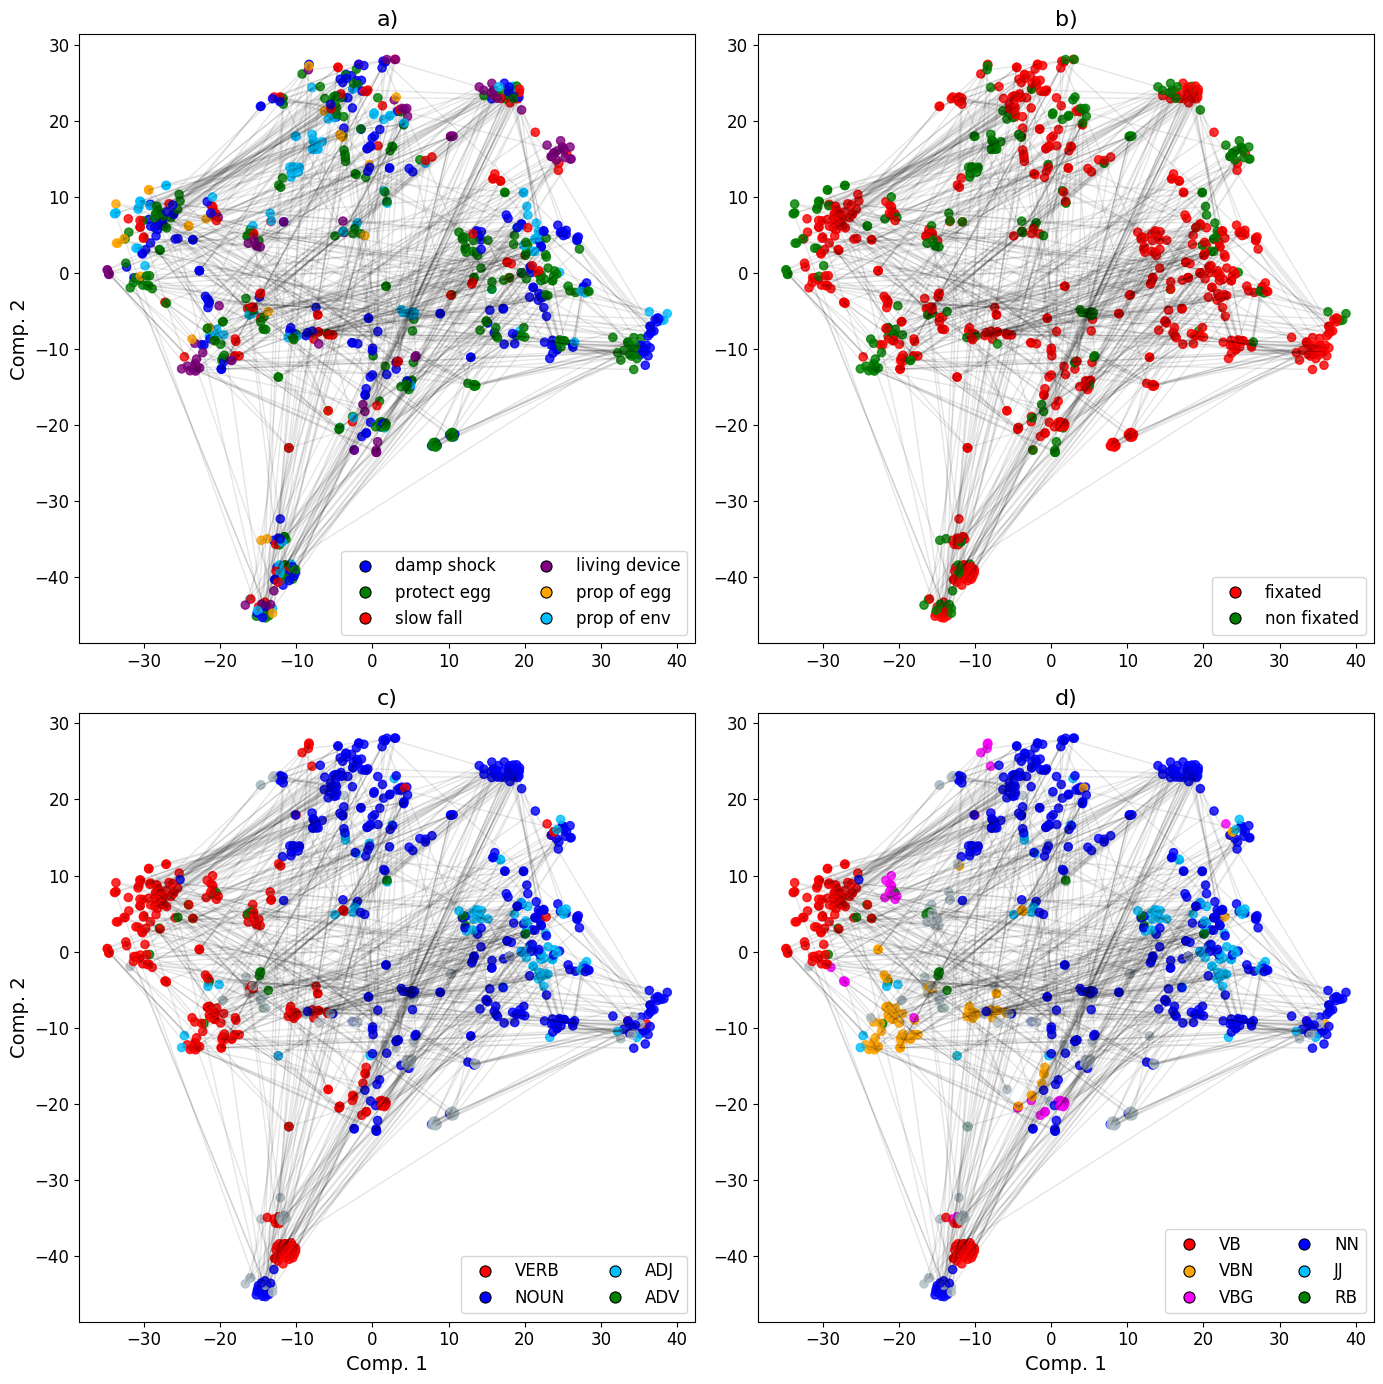

In [ ]:
# Set color variables
color_vars = [
    ("answ_category",  palettes['category']),
    ("answ_fixation",  palettes['fixation']),
    ("token_pos",      palettes['token_pos']),
    ("token_tag",      palettes['token_tag']),
    #("prompt_shot",    palettes['shot']),
    #("prompt_config",  palettes['prompt_config'])
]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

df = df.sort_values(["prompt_id", "step"])

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

axes = axes.flatten()

for ax, (color_var, palette) in zip(axes, color_vars):
    for seq in df["prompt_id"].unique():
        sub = df[df["prompt_id"] == seq].copy()
        #colors = sub[color_var].map(palette).fillna("#CCFF00")
        colors = sub[color_var].map(palette).fillna("#B0BEC5")

        # Plot sequence line
        ax.plot(sub["x"], sub["y"], color="black", alpha=0.1, linewidth=1)
        # Plot points
        ax.scatter(sub["x"], sub["y"], s=35, c=colors, alpha=0.8)

        # Legend
        handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                linestyle='',
                markerfacecolor=color,
                markeredgecolor="black",   # black outline
                markeredgewidth=0.8,       # optional: thickness of the border
                markersize=8,
                label=label.replace("_", " ")
            )
            for label, color in palette.items()
        ]

        # Decide number of columns
        ncol = 2 if len(palette) > 3 else 1
        ax.legend(handles=handles, loc="lower right", frameon=True, ncol=ncol)

    # Title
    color_var_to_panel = {"answ_category": "a)", "answ_fixation": "b)", "token_pos": "c)", "token_tag": "d)"}
    ax.set_title(f"{color_var_to_panel[color_var]}")

    if ax in [axes[2], axes[3]]:   # bottom row
      ax.set_xlabel("Comp. 1")
    else:
        ax.set_xlabel("")

    if ax in [axes[0], axes[2]]:   # left column
        ax.set_ylabel("Comp. 2")
    else:
        ax.set_ylabel("")

    ax.axis("equal")

# Save Svg
plt.savefig("/content/drive/MyDrive/data/final_hidden_states_figure.png", bbox_inches="tight")

plt.tight_layout()
plt.show()

## Interactive Plotly

In [ ]:
# Choose which variable to color by
color_var = "token_tag"  # "answ_category", "answ_fixation",  "token_pos", "token_tag"
marker_alpha = 0.8
line_alpha   = 0.2
show_text = False

# Choose palette
if color_var in ["prompt_category", "answ_category"]:
    palette = palettes["category"]
elif color_var in ["prompt_fixation", "answ_fixation"]:
    palette = palettes["fixation"]
elif color_var == "token_pos":
    palette = palettes["token_pos"]
elif color_var == "token_tag":
    palette = palettes["token_tag"]
else:
    raise ValueError("Wrong color variable")

# Build figure
fig = go.Figure()

df = df.sort_values(["prompt_id", "step"])

for seq in df["prompt_id"].unique():
    sub = df[df["prompt_id"] == seq].copy()

    #colors = sub[color_var].map(palette).fillna("#CCFF00")
    colors = sub[color_var].map(palette).fillna("#B0BEC5")

    marker_colors = [rgba_color(c, marker_alpha) for c in colors]
    #line_colors   = [rgba_color(c, line_alpha) for c in colors]

    # Build hovertemplate per token
    hover_text = [
        (
            f"<b>prompt_id:</b> {row.prompt_id}<br>"
            f"<b>step:</b> {row.step}<br>"
            f"<b>token_pos:</b> {row["token_pos"]}<br>"
            f"<b>token_tag:</b> {row["token_tag"]}<br>"
            f"<b>token:</b> {row.token_str}<br>"
            "<b>top-k:</b><br>"
            + "<br>".join([
                f"{i+1}. {tok} ({prob:.2%})"
                for i, (tok, prob) in enumerate(zip(row.topk_str, row.topk_prob))
            ])
        )
        for _, row in sub.iterrows()
    ]

    fig.add_trace(
        go.Scatter(

            x=sub["x"],
            y=sub["y"],
            mode="lines+markers+text" if show_text else "lines+markers",
            name=f"Seq. {seq}",

            # Text
            text=sub["token_str"],
            textposition="top center",
            textfont=dict(size=10),

            # Marker color
            #marker=dict(size=step_scaled, color=marker_colors),
            marker=dict(size=7, color=marker_colors),

            # Line color
            #line=dict(color=line_colors[0] if len(line_colors) > 0 else "rgba(0,0,0,0.3)", width=2),
            line=dict(color=f"rgba(160,160,160,{line_alpha})", width=1),

            # Hover
            hovertext=hover_text,
            hovertemplate="%{hovertext}<extra></extra>",

            # Legend
            legendgroup="sequences",
            legendgrouptitle_text="Sequences",
            legendrank=1,
            showlegend=False # True to show original color
        )
    )

    # Dummy legend: a black marker + line legend for the sequences

    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="lines+markers",
            name=f"Seq. {seq}",
            marker=dict(size=7, color="black"),
            line=dict(color="black", width=1),
            legendgrouptitle_text="Sequences",
            legendgroup="sequences",
            legendrank=1,
            showlegend=True, # override legend marker color
        )
    )


# Add color legend:
for label, color in palette.items():
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(size=10, color=color, opacity=marker_alpha, line=dict(color="black", width=1)),
            name=label.replace("_", " "),
            legendgroup="colors",
            legendgrouptitle_text="Clustering",
            legendrank=0,  # put color legend first
            showlegend=True,
        )
    )

fig.update_layout(
    title=(
        f"Final Hidden States — Llama-3.1-8B-Instruct"
    ),
    xaxis_title="Comp. 1",
    yaxis_title="Comp. 2",
    legend_title="",
    template="plotly_white",
    width=800,
    height=800,
    xaxis=dict(scaleratio=1),
    yaxis=dict(scaleanchor="x", scaleratio=1),
)

## Zoom in

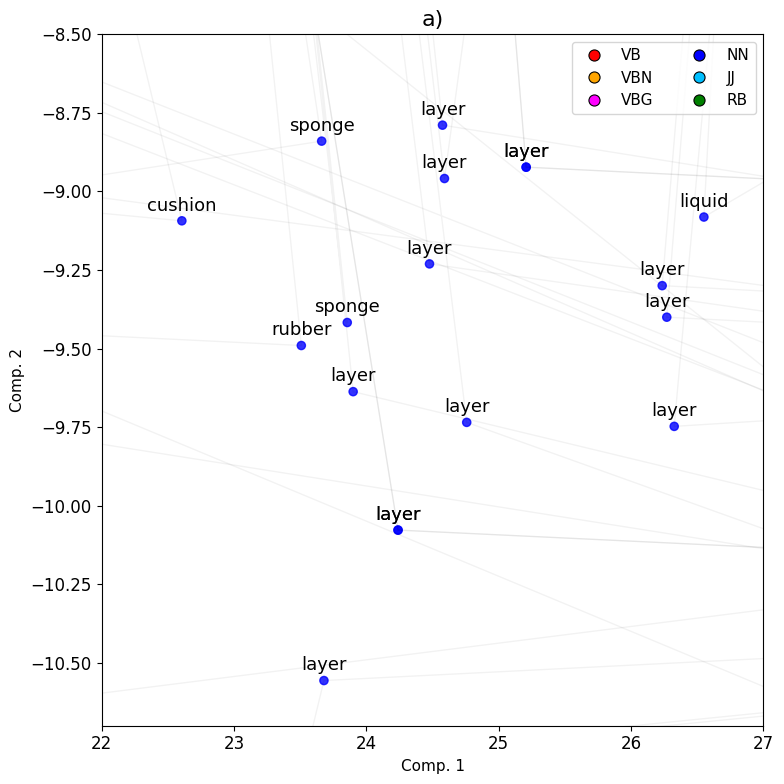

In [ ]:
# Choose the palette you want to use
color_var = "token_tag"
palette = palettes[color_var]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Zoom coordinates

# NN
y0, y1 = -10.7, -8.5
x0, x1 = 22, 27
title_str = 'a)' ; zoom = "1"

# VB
#y0, y1 = 6.8, 10
#x0, x1 = -31, -26
#title_str = 'b)'; zoom = "2"

# VBN
#y0, y1 = -13, -11.5
#x0, x1 = -25, -22
#title_str = 'c)'; zoom = "3"


df = df.sort_values(["prompt_id", "step"])

# Single Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

for seq in df["prompt_id"].unique():
    sub = df[df["prompt_id"] == seq].copy()
    colors = sub[color_var].map(palette).fillna("#B0BEC5")

    # Plot sequence line
    ax.plot(sub["x"], sub["y"], color="black", alpha=0.05, linewidth=1)

    # Plot points
    ax.scatter(sub["x"], sub["y"], s=35, c=colors, alpha=0.8)

    # Add text labels
    label_dx = 0.09   # horizontal offset
    label_dy = 0.02   # vertical offset
    for _, row in sub.iterrows():
        if x0 <= row["x"] <= x1 and y0 <= row["y"] <= y1:
            ax.text(
                row["x"],
                row["y"] + label_dy,
                row["token_str"],
                fontsize=13,
                ha='center',    # anchor left of text block
                va='bottom'     # anchor bottom so text moves up/right
            )

# Legend
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        markersize=8,
        label=label.replace("_", " ")
    )
    for label, color in palette.items()
]


ncol = 2 if len(palette) > 3 else 1
ax.legend(handles=handles, loc="upper right", frameon=True, ncol=ncol)


# Title and labels
ax.set_title(f"{title_str}") # ax.set_title(color_var)
ax.set_xlabel("Comp. 1", fontsize=11)
ax.set_ylabel("Comp. 2", fontsize=11)

# Zoom in
ax.set_xlim(x0, x1)   # x-range
ax.set_ylim(y0, y1)   # y-range

# Save svg
#plt.savefig(f"/content/drive/MyDrive/data/final_hidden_states_zoom_{zoom}.svg", bbox_inches="tight")

plt.tight_layout()
plt.show()

## Create HTML

In [ ]:
# Create html
plot_div = fig.to_html(full_html=False, include_plotlyjs="cdn")

# According to mask
'''
sequence_blocks = []
for seq, group in df.groupby("prompt_id"):
    gen_text  = " ".join(group["token_str"].astype(str).tolist())
    sequence_blocks.append(f"<p><b>Sequence {seq}</b></p><pre>{gen_text }</pre>")
'''

# All tokens
sequence_blocks = []
for pid, prompt, seq, valid in sorted(zip(data["prompt_id"], data['prompt'], data["new_token_strings"], data['valid_answ']), key=lambda x: np.ravel(x[0])[0]):
  gen_text  = " ".join(seq)
  prompt_text = prompt[0]
  valid_answ  = valid[0]
  prompt_id   = pid[0]

  # Visualization fix:----------------------------------------------
  # Fix a small typos in a prompt without re-running the analysis
  #if prompt_id > 80:
  #  df_prompt = pd.read_excel("/content/drive/MyDrive/data/prompts.xlsx") # load prompts
  #  prompt_text = df_prompt.loc[df_prompt['prompt_id'] == prompt_id, 'prompt'].iloc[0] # get the corrected version of the prompt
  # ----------------------------------------------------------------
  if valid_answ:
    sequence_blocks.append(f"<p><b>Sequence {prompt_id}</b></p><pre>{prompt_text} <b>{gen_text}</b></pre>")

sequences_html = "\n".join(sequence_blocks)

full_html = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>t-SNE Final Hidden State Space</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 40px;
            background-color: #f9f9f9;
            color: #333;
        }}
        #plot {{
            display: flex;
            justify-content: center;
            align-items: center;
            margin-bottom: 30px;
        }}
        #sequences {{
            max-width: 900px;
            margin: 0 auto;
            background: #fff;
            border-radius: 10px;
            padding: 20px;
            box-shadow: 0 0 10px rgba(0,0,0,0.1);
        }}
        pre {{
            background: #f0f0f0;
            padding: 10px;
            border-radius: 6px;
            white-space: pre-wrap;
            word-wrap: break-word;
            font-family: Arial, sans-serif;
        }}
        button {{
            display: block;
            margin: 0 auto 20px auto;
            padding: 10px 20px;
            background-color: #808080; /* gray */
            color: white;
            border: none;
            border-radius: 6px;
            cursor: pointer;
            font-size: 14px;
            font-family: Arial, sans-serif;
        }}
        button:hover {{
            background-color: #6e6e6e;
        }}
    </style>
</head>
<body>

<button id="toggle-tokens">Toggle tokens</button>

<div id="plot">
{plot_div}
</div>

<div id="sequences">
{sequences_html}
</div>

<script>
document.addEventListener('DOMContentLoaded', function() {{
    var graphDiv = document.querySelector('#plot .plotly-graph-div');
    var btn = document.getElementById('toggle-tokens');

    if (!graphDiv || !btn || !window.Plotly) {{
        return;
    }}

    var labelsOn = false;

    btn.addEventListener('click', function() {{
        labelsOn = !labelsOn;
        var newMode = labelsOn ? 'lines+markers+text' : 'lines+markers';
        Plotly.restyle(graphDiv, 'mode', newMode);
    }});
}});
</script>

</body>
</html>
"""

# Save html
output_path = "/content/drive/MyDrive/data/final_hidden_states_d.html"
with open(output_path, "w", encoding="utf-8") as f:
    f.write(full_html)

HTML(full_html)


# Free Up GPU

In [ ]:
import gc
import torch

# 1. Delete all temporary variables safely
objs_to_delete = [
    "outputs",
    "input_ids",
    "attention_mask",
    "encodings",
    "hidden_states_per_step",
    "generated_ids",
    "step_last_token_hidden_tensor",
    "topk_probs_tensor",
    "topk_ids_tensor",
    "step_last_token_hidden_np",
    "new_token_ids_np",
    "topk_probs_np",
    "topk_ids_np",
]

for obj in objs_to_delete:
    if obj in globals():
        del globals()[obj]

# 2. Run Python garbage collector
gc.collect()

# 3. Clear CUDA caches and reset memory state
torch.cuda.empty_cache()  # frees cached blocks
torch.cuda.ipc_collect()  # clears interprocess memory handles
torch.cuda.synchronize()  # ensure all pending ops complete

print("GPU memory cleaned.")

GPU memory cleaned.


# Classify Answers

In [ ]:
folder = "/content/drive/MyDrive/data/"

dfs = []

for filename in os.listdir(folder):
    if filename.startswith("answer") and filename.endswith((".xlsx")):
        filepath = os.path.join(folder, filename)
        df = pd.read_excel(filepath)
        dfs.append(df)

df_merge = pd.concat(dfs, axis=0, ignore_index=True)
df_merge['answ_category'] = "" # initialize an empty column for manula calssification

# Save the file for manual classification
df_merge.to_excel("/content/drive/MyDrive/data/all_answers.xlsx", index = False)
df_merge

,prompt_id,answ,answ_category
0,1,:\nThe egg should be dropped from a height of ...,
1,5,"Problem: Design the most creative, novel, and...",
2,9,\nDrop the egg in a container filled with a th...,
3,13,A thick layer of sand is used as the landing ...,
4,17,\nDropping the egg into a large container fill...,
...,...,...,...
83,71,\nUse a vacuum chamber or a container filled w...,
84,75,\nDrop the egg from a height of 10 m inside a ...,
85,79,Use a water pool with a depth of 10 m to drop...,
86,83,\nDrop the egg from a height of 10 m in a cont...,
